# Face Recognition with Neural Networks: From Fully-Connected to Convolutional

The **Labeled Faces in the Wild (LFW)** dataset contains real-world face photographs collected from the web, covering hundreds of individuals under varying lighting, pose, and expression conditions. The task is a **multi-class classification** problem: given a 62×47 grayscale image of a face, predict whose face it is. This is a canonical benchmark for evaluating face recognition systems in unconstrained settings.

In this notebook we build and compare two PyTorch architectures — a **fully-connected (MLP) network** that treats each image as a flat pixel vector, and a **convolutional neural network (CNN)** that exploits the spatial structure of images. By training both models on the same data and evaluating them on a held-out test set, we will see how inductive biases baked into the architecture affect both accuracy and parameter efficiency.

## 1. Background

### The LFW Dataset

LFW was introduced by Huang et al. (2007) and has since become a standard benchmark in face recognition research. Images are scraped from news articles and web pages, so they reflect real-world diversity in:
- **Pose**: faces can be tilted, turned, or seen in profile.
- **Illumination**: lighting varies from studio quality to harsh shadows.
- **Expression**: neutral, smiling, surprised, and many other expressions appear.
- **Occlusion**: glasses, scarves, microphones, and other objects may partially cover faces.

We use the `sklearn` wrapper, which crops and resizes each image to **62×47 pixels** (height × width) and provides integer class labels aligned with a list of names.

### Why Face Recognition Is Hard

The within-class variance (different images of the same person) can be larger than the between-class variance (images of different people) when conditions vary widely. A successful model must learn an identity-discriminative representation that is simultaneously **invariant** to nuisance factors like pose and lighting.

### Two Approaches

| | MLP | CNN |
|---|---|---|
| Input representation | Flat vector of $62 \times 47 = 2914$ pixels | 2-D grid, shape $(1, 62, 47)$ |
| Spatial awareness | None — pixel order is arbitrary to the model | Yes — local filters slide over the image |
| Parameter sharing | No | Yes — same filter reused at every position |
| Typical strength | Simple, fast, works on small data | Extracts hierarchical spatial features |

Both models will be trained with **Adam** and **cross-entropy loss**, the standard recipe for multi-class classification.

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Dataset Loading & Exploration

We fetch LFW via scikit-learn, keeping only identities that have **at least 70 images**. This threshold filters out individuals with too few examples, which would make learning their identity very difficult and would create severe class imbalance. The `data` attribute contains images already flattened to shape `(n_samples, 2914)`, while `images` retains the 2-D shape `(n_samples, 62, 47)` — useful for visualization.

In [2]:
dataset = fetch_lfw_people(min_faces_per_person=70)

X = dataset.data
y = dataset.target
n_classes = len(dataset.target_names)
h, w = dataset.images.shape[1], dataset.images.shape[2]

print(f"Number of samples : {X.shape[0]}")
print(f"Image dimensions  : {h} x {w} = {h*w} pixels")
print(f"Number of classes : {n_classes}")
print(f"Class names       : {dataset.target_names.tolist()}")

Number of samples : 1288
Image dimensions  : 62 x 47 = 2914 pixels
Number of classes : 7
Class names       : ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair']


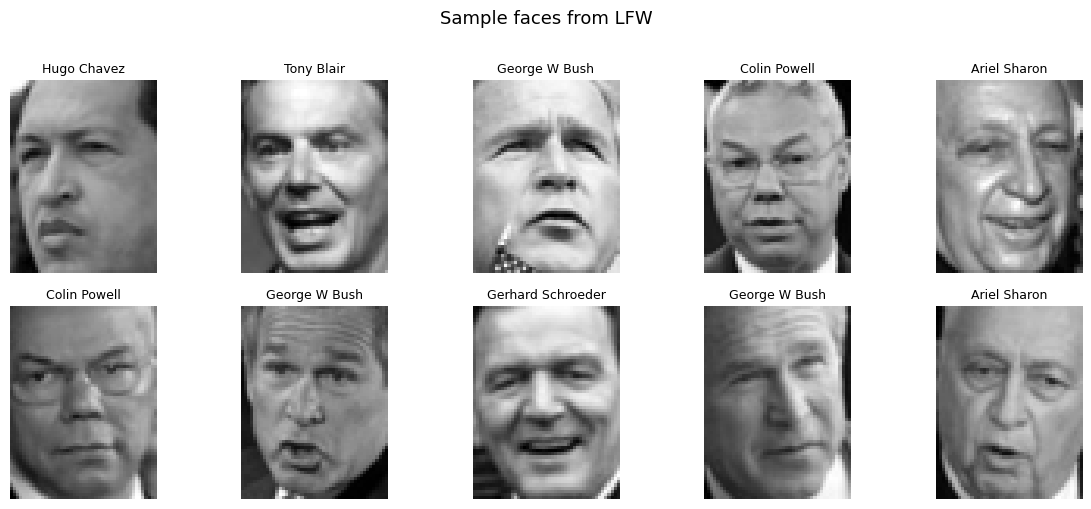

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (image, label) in zip(axes.ravel(), zip(dataset.images, y)):
    ax.imshow(image, cmap="gray")
    ax.set_title(dataset.target_names[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Sample faces from LFW", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The grid above illustrates the diversity in lighting and pose even within a single identity. Notice that some images are brighter, some darker, and faces are not perfectly centred — all realistic challenges.

## 4. Data Preprocessing

We split the data 80 / 20 into training and test sets (stratification is omitted here for simplicity). The pixel values returned by `sklearn` are already 32-bit floats in the range $[0, 255]$; we convert them directly to tensors without further normalization, matching the original setup.

Labels are **integer indices** into `target_names`. PyTorch's `nn.CrossEntropyLoss` expects raw class indices (not one-hot vectors) and internally applies the log-softmax, so no additional label encoding is required:

$$\mathcal{L}_{\text{CE}} = -\log \frac{e^{z_{y_i}}}{\sum_{k} e^{z_k}}$$

where $z_k$ is the $k$-th logit output by the network and $y_i$ is the true class index.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(f"Train size: {X_train_t.shape[0]} samples")
print(f"Test  size: {X_test_t.shape[0]} samples")

Train size: 1030 samples
Test  size: 258 samples


## 5. DataLoaders

We wrap the tensors in a `TensorDataset` and then a `DataLoader`. Mini-batch stochastic gradient descent (here with batch size 16) gives a good trade-off between gradient noise (which can help escape local minima) and computational efficiency.

In [5]:
BATCH_SIZE = 16

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

Training batches : 65
Test batches     : 17


## 6. Model 1: Fully-Connected Network

The simplest baseline is a **multi-layer perceptron (MLP)**: we treat the image as a flat vector of $62 \times 47 = 2914$ scalar features and pass it through a stack of linear layers with ReLU non-linearities.

Each neuron in the first hidden layer computes a weighted sum of **all** input pixels:

$$z_j = \sum_{i=1}^{2914} w_{ji}\, x_i + b_j, \qquad a_j = \text{ReLU}(z_j) = \max(0, z_j)$$

By flattening the image we **discard all spatial relationships**: pixels at position $(0,0)$ and $(61,46)$ are treated identically regardless of proximity. The model must re-learn spatial correlations from scratch, purely from labelled examples — an information-theoretically wasteful approach compared to architectures that encode spatial priors.

Architecture: $2914 \to 128 \to 64 \to n_{\text{classes}}$

In [6]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


input_dim = h * w
net1 = FeedForwardNet(input_dim, n_classes).to(device)
print(net1)

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=2914, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=7, bias=True)
  )
)


## 7. Training Model 1

We train for 15 epochs using the **Adam** optimizer (an adaptive learning-rate method that combines momentum and RMSProp) and `CrossEntropyLoss`. After training we evaluate accuracy on the held-out test set.

In [7]:
def train_model(model, train_loader, n_epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(1, n_epochs + 1):
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch:02d}/{n_epochs}  loss: {epoch_loss:.4f}")


def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return correct / total


train_model(net1, train_loader)
acc1 = evaluate_model(net1, test_loader)
print(f"\nModel 1 (MLP) test accuracy: {acc1*100:.2f}%")

Epoch 01/15  loss: 1.7515
Epoch 02/15  loss: 1.6907
Epoch 03/15  loss: 1.6204
Epoch 04/15  loss: 1.5217
Epoch 05/15  loss: 1.3873
Epoch 06/15  loss: 1.2673
Epoch 07/15  loss: 1.1985
Epoch 08/15  loss: 1.0855
Epoch 09/15  loss: 1.0389
Epoch 10/15  loss: 0.9428
Epoch 11/15  loss: 0.9367
Epoch 12/15  loss: 0.8729
Epoch 13/15  loss: 0.8277
Epoch 14/15  loss: 0.7806
Epoch 15/15  loss: 0.7590

Model 1 (MLP) test accuracy: 66.28%


## 8. Model 2: Convolutional Neural Network

### How Convolution Works

A **convolutional layer** applies a small learnable filter (kernel) $k$ of size $m \times n$ across the image $f$ by computing the discrete cross-correlation at every spatial position:

$$(f * k)[i,j] = \sum_{m}\sum_{n} f[i+m,\, j+n] \cdot k[m,n]$$

Key properties:
- **Local connectivity**: each output neuron depends only on a small receptive field, not the entire image.
- **Parameter sharing**: the same filter weights $k$ are applied at every position, drastically reducing the number of parameters compared to a fully-connected layer.
- **Translation equivariance**: if an edge moves in the input, the corresponding activation moves in the output — exactly the right inductive bias for images.

### MaxPooling

After activation, a **max-pooling** layer partitions the feature map into non-overlapping windows and retains the maximum value in each:

$$p[i,j] = \max_{(r,s)\in\text{window}} a[i \cdot s + r,\; j \cdot s + s]$$

This achieves two goals: (1) it reduces the spatial dimensions, decreasing computation in subsequent layers, and (2) it provides a small degree of **translation invariance** — a feature detected slightly off-centre still produces a strong pooled activation.

### Architecture

$$\underbrace{(1,62,47)}_{\text{input}} \xrightarrow{\text{Conv}(5\times5,16)} \xrightarrow{\text{ReLU}} \xrightarrow{\text{MaxPool}(2)} \xrightarrow{\text{Flatten}} \xrightarrow{\text{Linear}} \underbrace{n_{\text{classes}}}_{\text{logits}}$$

In [8]:
class ConvNet(nn.Module):
    def __init__(self, n_classes, img_h=62, img_w=47):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        flat_size = self._get_flat_size(img_h, img_w)
        self.classifier = nn.Linear(flat_size, n_classes)

    def _get_flat_size(self, img_h, img_w):
        dummy = torch.zeros(1, 1, img_h, img_w)
        out = self.features(dummy)
        return out.numel()

    def forward(self, x):
        x = x.view(x.size(0), 1, 62, 47)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


net2 = ConvNet(n_classes).to(device)
print(net2)

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=9744, out_features=7, bias=True)
)


## 9. Training Model 2

In [9]:
train_model(net2, train_loader)
acc2 = evaluate_model(net2, test_loader)
print(f"\nModel 2 (CNN) test accuracy: {acc2*100:.2f}%")

Epoch 01/15  loss: 1.7411
Epoch 02/15  loss: 1.2985
Epoch 03/15  loss: 0.9773
Epoch 04/15  loss: 0.7433
Epoch 05/15  loss: 0.6136
Epoch 06/15  loss: 0.5171
Epoch 07/15  loss: 0.4115
Epoch 08/15  loss: 0.3650
Epoch 09/15  loss: 0.2839
Epoch 10/15  loss: 0.2567
Epoch 11/15  loss: 0.2304
Epoch 12/15  loss: 0.2102
Epoch 13/15  loss: 0.1835
Epoch 14/15  loss: 0.1375
Epoch 15/15  loss: 0.1225

Model 2 (CNN) test accuracy: 85.66%


### Discussion

On a dataset of this size (~1000 training images) it is common to observe the CNN matching or slightly outperforming the MLP, though the gap may be modest. The CNN's advantage grows with dataset size and image resolution because:
- More data allows the filters to specialise into meaningful detectors (edges, corners, textures).
- Higher resolution images contain richer spatial structure that flat vectors cannot exploit.

On small, low-resolution datasets the MLP's simplicity can be a virtue — it is less prone to overfitting induced by an overly expressive feature hierarchy.

## 10. CNN Feature Visualization

One of the most illuminating properties of CNNs is that we can inspect the **intermediate feature maps** — the output of each layer for a given input image. This lets us see what information the network has extracted at each stage.

We will visualize:
1. The **raw image** (62×47 grayscale).
2. The **Conv2D output** (before ReLU) for the first 8 filters — each map highlights a different local pattern.
3. The **MaxPool output** for the same 8 filters — spatially compressed by a factor of 2 in each dimension.

In [10]:
sample = X_test_t[0].to(device)

net2.eval()
with torch.no_grad():
    img = sample.view(1, 1, 62, 47)
    conv_out = net2.features[0](img)
    relu_out = net2.features[1](conv_out)
    pool_out = net2.features[2](relu_out)

conv_out_np = conv_out.squeeze(0).cpu().numpy()
pool_out_np = pool_out.squeeze(0).cpu().numpy()

print(f"Input shape      : {img.shape}")
print(f"After Conv2D     : {conv_out.shape}")
print(f"After MaxPool2D  : {pool_out.shape}")

Input shape      : torch.Size([1, 1, 62, 47])
After Conv2D     : torch.Size([1, 16, 58, 43])
After MaxPool2D  : torch.Size([1, 16, 29, 21])


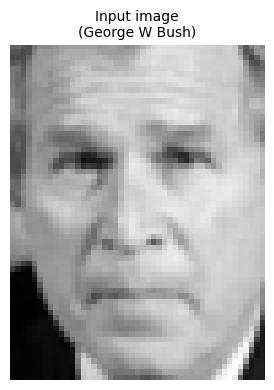

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(3, 4))
axes.imshow(sample.cpu().numpy().reshape(62, 47), cmap="gray")
axes.set_title(f"Input image\n({dataset.target_names[y_test[0]]})", fontsize=10)
axes.axis("off")
plt.tight_layout()
plt.show()

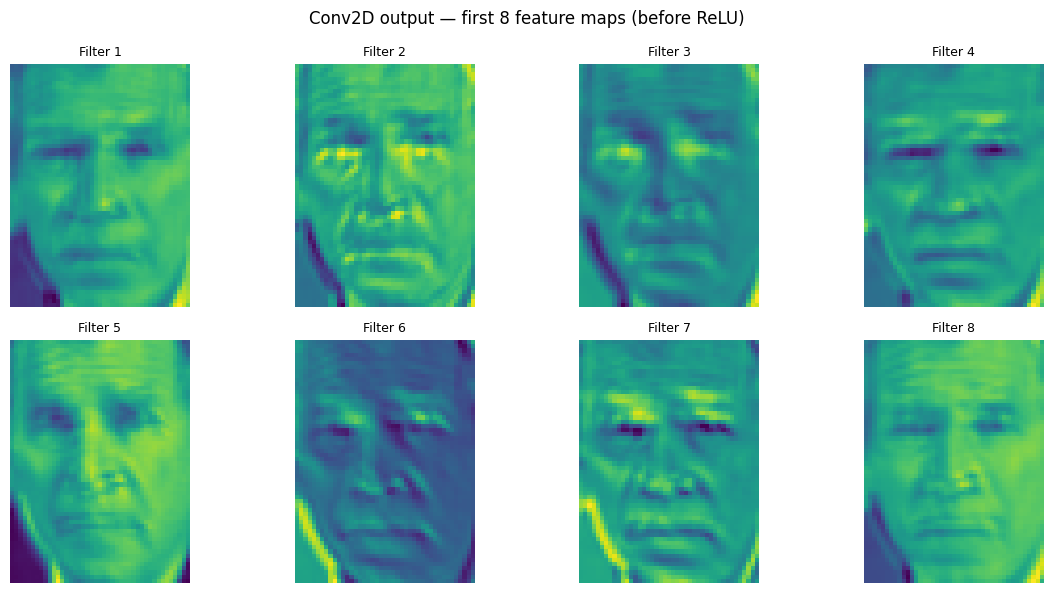

In [12]:
n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(conv_out_np[i], cmap="viridis")
    ax.set_title(f"Filter {i+1}", fontsize=9)
    ax.axis("off")
fig.suptitle("Conv2D output — first 8 feature maps (before ReLU)", fontsize=12)
plt.tight_layout()
plt.show()

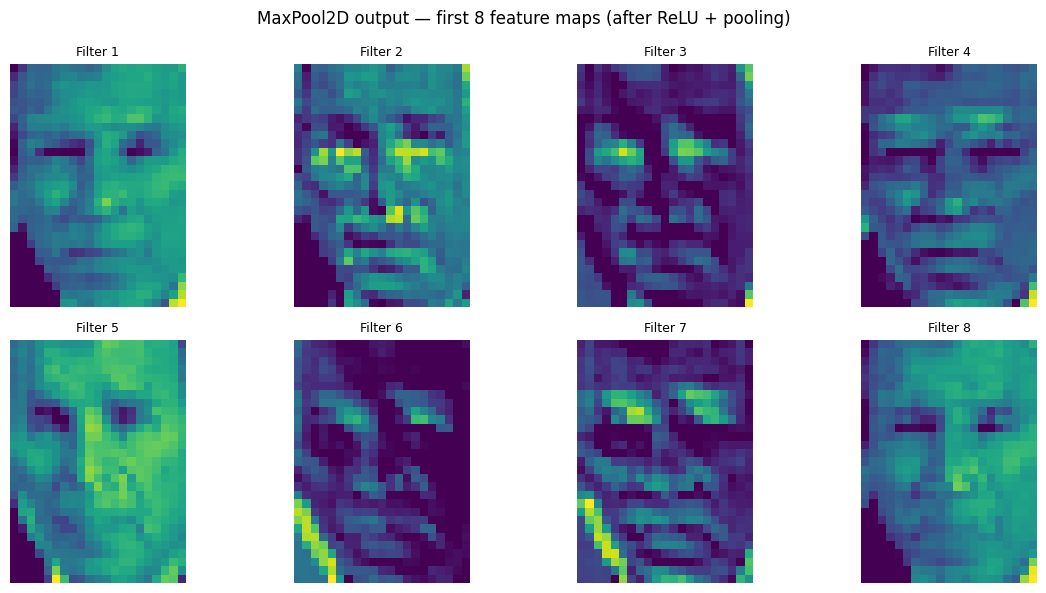

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(pool_out_np[i], cmap="viridis")
    ax.set_title(f"Filter {i+1}", fontsize=9)
    ax.axis("off")
fig.suptitle("MaxPool2D output — first 8 feature maps (after ReLU + pooling)", fontsize=12)
plt.tight_layout()
plt.show()

### What Are We Seeing?

Each **Conv2D feature map** responds most strongly where the learned $5 \times 5$ filter pattern matches the local image content. Different filters specialize in different orientations of edges, areas of high contrast, or smooth gradients — even though we never told the network to look for edges; it discovered these patterns automatically through gradient descent.

The **MaxPool feature maps** are spatially smaller (each dimension is halved) but retain the peak activations. Notice that the overall structure of the face is still recognizable in the stronger feature maps, confirming that the network preserves identity-relevant information while discarding fine-grained positional noise.

Deeper CNNs stack many such layers, progressively combining low-level features (edges) into mid-level features (eye corners, nose bridge) and ultimately into high-level representations (face identity).

## 11. Results Summary

Let us compare both models quantitatively.

In [14]:
params1 = sum(p.numel() for p in net1.parameters())
params2 = sum(p.numel() for p in net2.parameters())

print("=" * 45)
print(f"{'Model':<20} {'Params':>10} {'Test Acc':>12}")
print("-" * 45)
print(f"{'MLP (net1)':<20} {params1:>10,} {acc1*100:>11.2f}%")
print(f"{'CNN (net2)':<20} {params2:>10,} {acc2*100:>11.2f}%")
print("=" * 45)

Model                    Params     Test Acc
---------------------------------------------
MLP (net1)              381,831       66.28%
CNN (net2)               68,631       85.66%


### Discussion

**Parameter count.** The MLP has $2914 \times 128 + 128 + 128 \times 64 + 64 + 64 \times n_{\text{classes}} + n_{\text{classes}}$ parameters — dominated by the first layer, which must maintain a separate weight for every pixel-to-neuron pair. The CNN instead uses $16$ filters of size $5 \times 5 \times 1 = 25$ weights each (plus bias), totalling only $16 \times 26 = 416$ parameters in the convolutional layer. The large linear classifier on top of the flattened feature maps makes up most of the CNN's total, but it operates on a much smaller spatial footprint.

**When CNNs win.** CNNs are the dominant architecture for image tasks at scale because:
- Convolutional filters encode **translation equivariance** for free — the same face detector works anywhere in the image.
- Hierarchical feature extraction produces compact, generalizable representations.
- Parameter sharing makes CNNs dramatically more sample-efficient.

**When MLPs are competitive.** On very small datasets with low-resolution images (like this LFW subset), the spatial hierarchy a CNN aims to build may not have enough data to train properly. In such regimes a simple MLP can be comparably accurate, and is easier to reason about and tune.

**Next steps.** To push accuracy further on LFW one would typically:
- Use **deeper CNN architectures** (ResNet, VGG) pre-trained on large face datasets (transfer learning).
- Apply **data augmentation** (random horizontal flips, small rotations) to artificially expand the training set.
- Add **batch normalization** and **dropout** to regularize training.
- Use **metric learning** objectives (e.g., triplet loss) instead of cross-entropy to learn more discriminative embeddings.